In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

monthly_usage = np.array([2,4,6,8,10,12,14,16,18,20,3,5,7,9,11,13,15,17,19,21]).reshape(-1,1)
premium_subscription = np.array([0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1])
df = pd.DataFrame({"Monthly AI Usage (Hours)": monthly_usage.flatten(),
                   "Premium Subscription": premium_subscription})
print("Dataset:")
print(df)

Dataset:
    Monthly AI Usage (Hours)  Premium Subscription
0                          2                     0
1                          4                     0
2                          6                     0
3                          8                     0
4                         10                     0
5                         12                     1
6                         14                     1
7                         16                     1
8                         18                     1
9                         20                     1
10                         3                     0
11                         5                     0
12                         7                     0
13                         9                     0
14                        11                     1
15                        13                     1
16                        15                     1
17                        17                     1
18                    

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(monthly_usage,premium_subscription,test_size=0.3,random_state=42)
print(f"\nTraining Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

model = LogisticRegression()
model.fit(X_train, y_train)
print(f"\nCoefficient : {model.coef_[0][0]:.4f}")
print(f"Intercept   : {model.intercept_[0]:.4f}")


Training Samples : 14
Testing Samples  : 6

Coefficient : 1.0321
Intercept   : -11.1740


In [21]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
new_usage = np.array([[15]])

prediction = model.predict(new_usage)[0]
probability = model.predict_proba(new_usage)[0]

print("-"*30)
print("NEW USER PREDICTION")
print("-"*30)
print(f"Monthly AI Usage = {new_usage[0][0]} Hours")
print(f"Prediction : {'PREMIUM SUBSCRIPTION' if prediction==1 else 'FREE PLAN'}")
print(f"Confidence : {max(probability)*100:.1f}%")

------------------------------
NEW USER PREDICTION
------------------------------
Monthly AI Usage = 15 Hours
Prediction : PREMIUM SUBSCRIPTION
Confidence : 98.7%


In [22]:
from sklearn.metrics import (confusion_matrix,classification_report,roc_auc_score)

accuracy = model.score(X_test,y_test)
cm = confusion_matrix(y_test,y_pred)
auc = roc_auc_score(y_test,y_pred_proba[:,1])

print("---"*20)
print("MODEL EVALUATION")
print("---"*20)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"AUC Score: {auc:.3f}")
print("Confusion Matrix")
print(cm)
print(f"\nTrue Negatives : {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives : {cm[1,1]}")
print("\nClassification Report\n")
print(classification_report(y_test,y_pred,target_names=["Free Plan","Premium Plan"]))

------------------------------------------------------------
MODEL EVALUATION
------------------------------------------------------------
Accuracy : 100.00%
AUC Score: 1.000
Confusion Matrix
[[2 0]
 [0 4]]

True Negatives : 2
False Positives: 0
False Negatives: 0
True Positives : 4

Classification Report

              precision    recall  f1-score   support

   Free Plan       1.00      1.00      1.00         2
Premium Plan       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



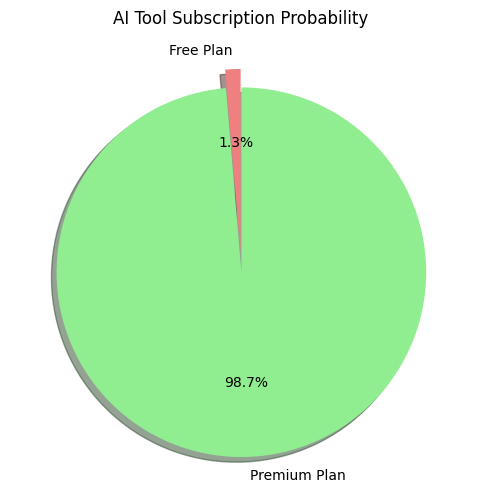

In [23]:
import matplotlib.pyplot as plt

labels = ["Free Plan", "Premium Plan"]
colors = ["lightcoral", "lightgreen"]

plt.figure(figsize=(6,6))
plt.pie(probability,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0.05, 0.05),
    shadow=True)
plt.title("AI Tool Subscription Probability")
plt.show()